# 🍷 Classificação da Qualidade de Vinhos
## Tech Challenge — Fase 2 | POSTECH DTAT

**Objetivo:** Prever se um vinho é de **alta qualidade (nota ≥ 7)** ou **baixa/média qualidade (nota < 7)** com base em suas características físico-químicas.


## 1. Imports e Configurações

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Carregamento dos Dados

In [38]:
df = pd.read_csv('WineQT.csv')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [39]:
df.shape

(1143, 13)

In [40]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Valores Nulos e Duplicatas

In [42]:
print("Valores nulos:")
print(df.isnull().sum())

print(f"\nRegistros duplicados: {df.duplicated().sum()}")

# Removendo a coluna Id (apenas identificador, sem valor preditivo)
# Feita após a verificação de duplicatas para não distorcer a contagem
df = df.drop(columns=['Id'])
print("\nColuna 'Id' removida.")


Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Registros duplicados: 0

Coluna 'Id' removida.


### 3.2 Variável Alvo

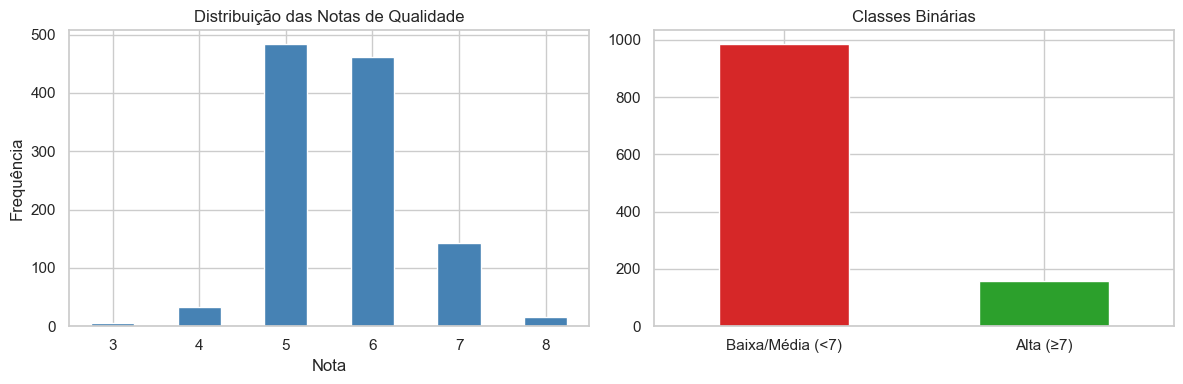

In [43]:
# Criando a classificação binária
df['quality_label'] = df['quality'].apply(lambda x: 'Alta (≥7)' if x >= 7 else 'Baixa/Média (<7)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição original
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição das Notas de Qualidade')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=0)

# Distribuição binária
df['quality_label'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#d62728', '#2ca02c'], edgecolor='white')
axes[1].set_title('Classes Binárias')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


> **Observação:** O dataset é desbalanceado — cerca de **86% das amostras** pertencem à classe Baixa/Média e apenas **14% à Alta Qualidade**. Isso deverá ser tratado no pré-processamento.


### 3.3 Distribuição das Features

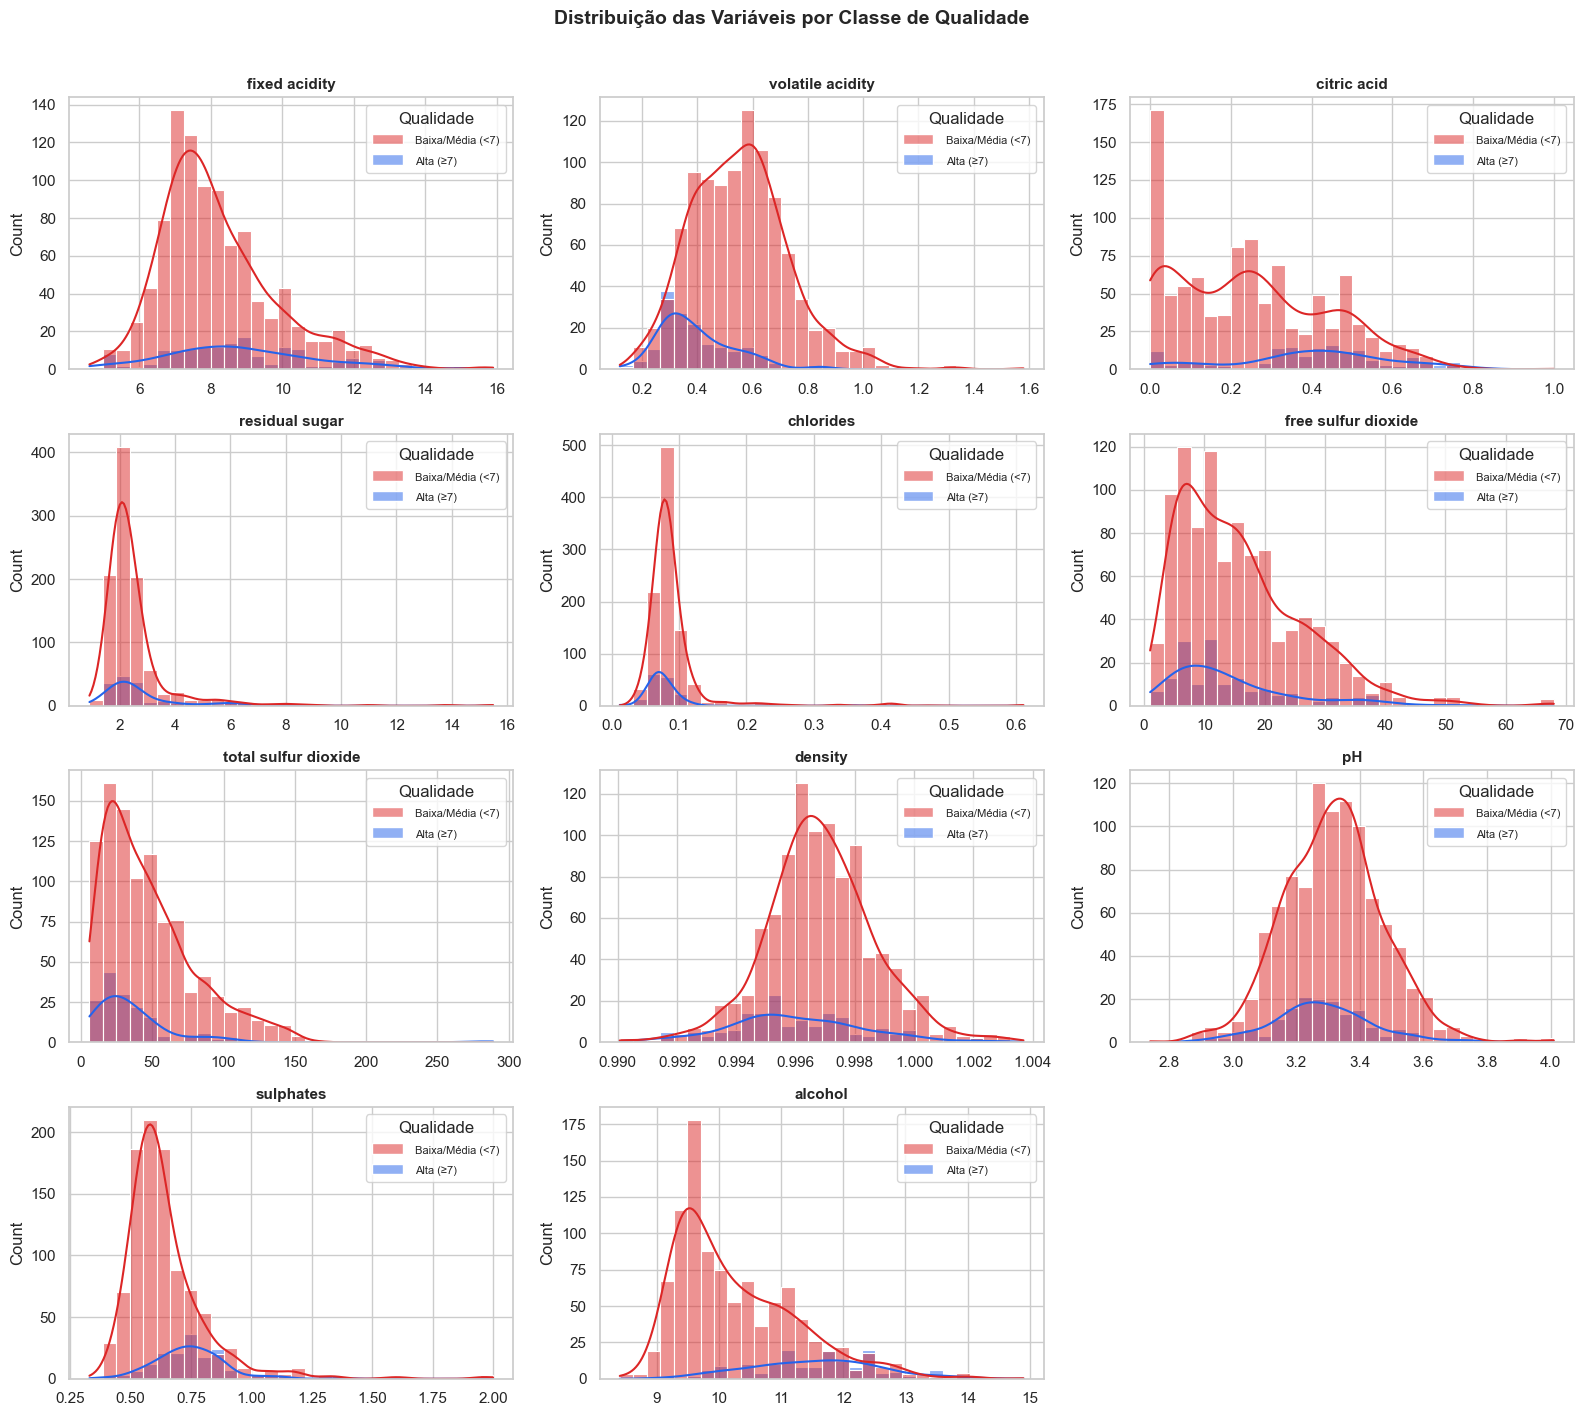

In [44]:
df['quality_label'] = df['quality'].apply(lambda x: 'Alta (≥7)' if x >= 7 else 'Baixa/Média (<7)')

features = [c for c in df.columns if c not in ['quality', 'quality_label', 'wine_type']]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.histplot(
        data=df, x=col, hue='quality_label',
        kde=True, ax=ax,
        palette={'Alta (≥7)': '#2563EB', 'Baixa/Média (<7)': '#DC2626'},
        alpha=0.5, bins=30
    )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    
    # Pega a legenda que o seaborn criou e ajusta o título
    legend = ax.get_legend()
    if legend:
        legend.set_title('Qualidade')
        for text in legend.get_texts():
            text.set_fontsize(8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis por Classe de Qualidade', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<Axes: >

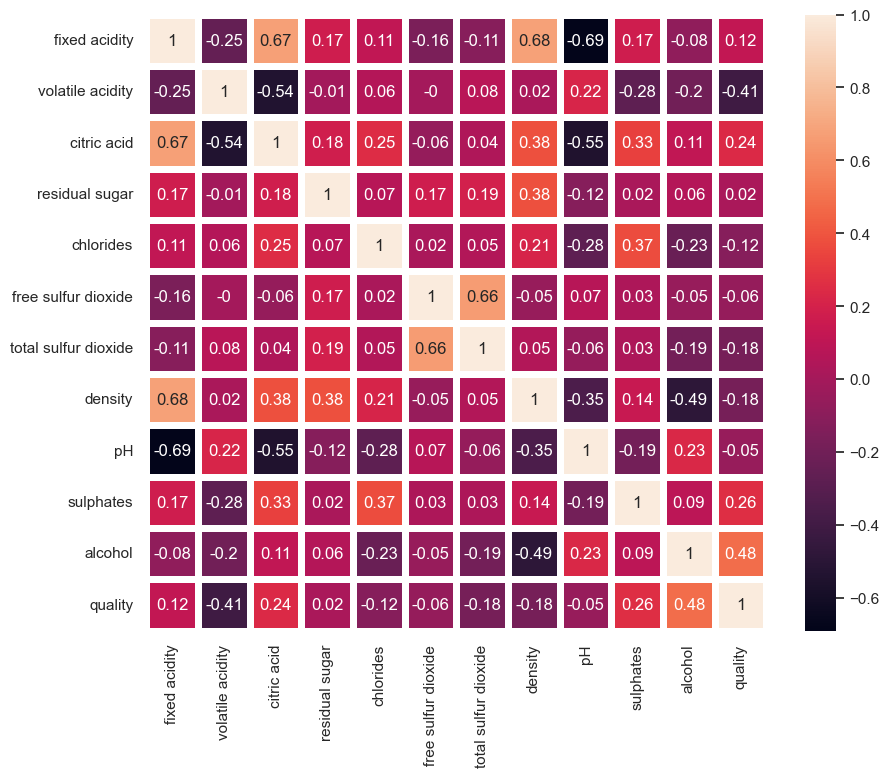

In [45]:
import seaborn as sb
correlation_matriz = df.drop(columns=['quality_label']).corr().round(2)
fix, ax = plt.subplots(figsize=(10, 8))
sb.heatmap(data = correlation_matriz, annot=True, linewidths=5, ax=ax)

### 3.4 Matriz de Correlação

### 3.5 Boxplots por Classe

C:\Users\Aline Azevedo\AppData\Local\Temp\ipykernel_12940\50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
C:\Users\Aline Azevedo\AppData\Local\Temp\ipykernel_12940\50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
C:\Users\Aline Azevedo\AppData\Local\Temp\ipykernel_12940\50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
C:\Users\Aline Azevedo\AppData\Loc

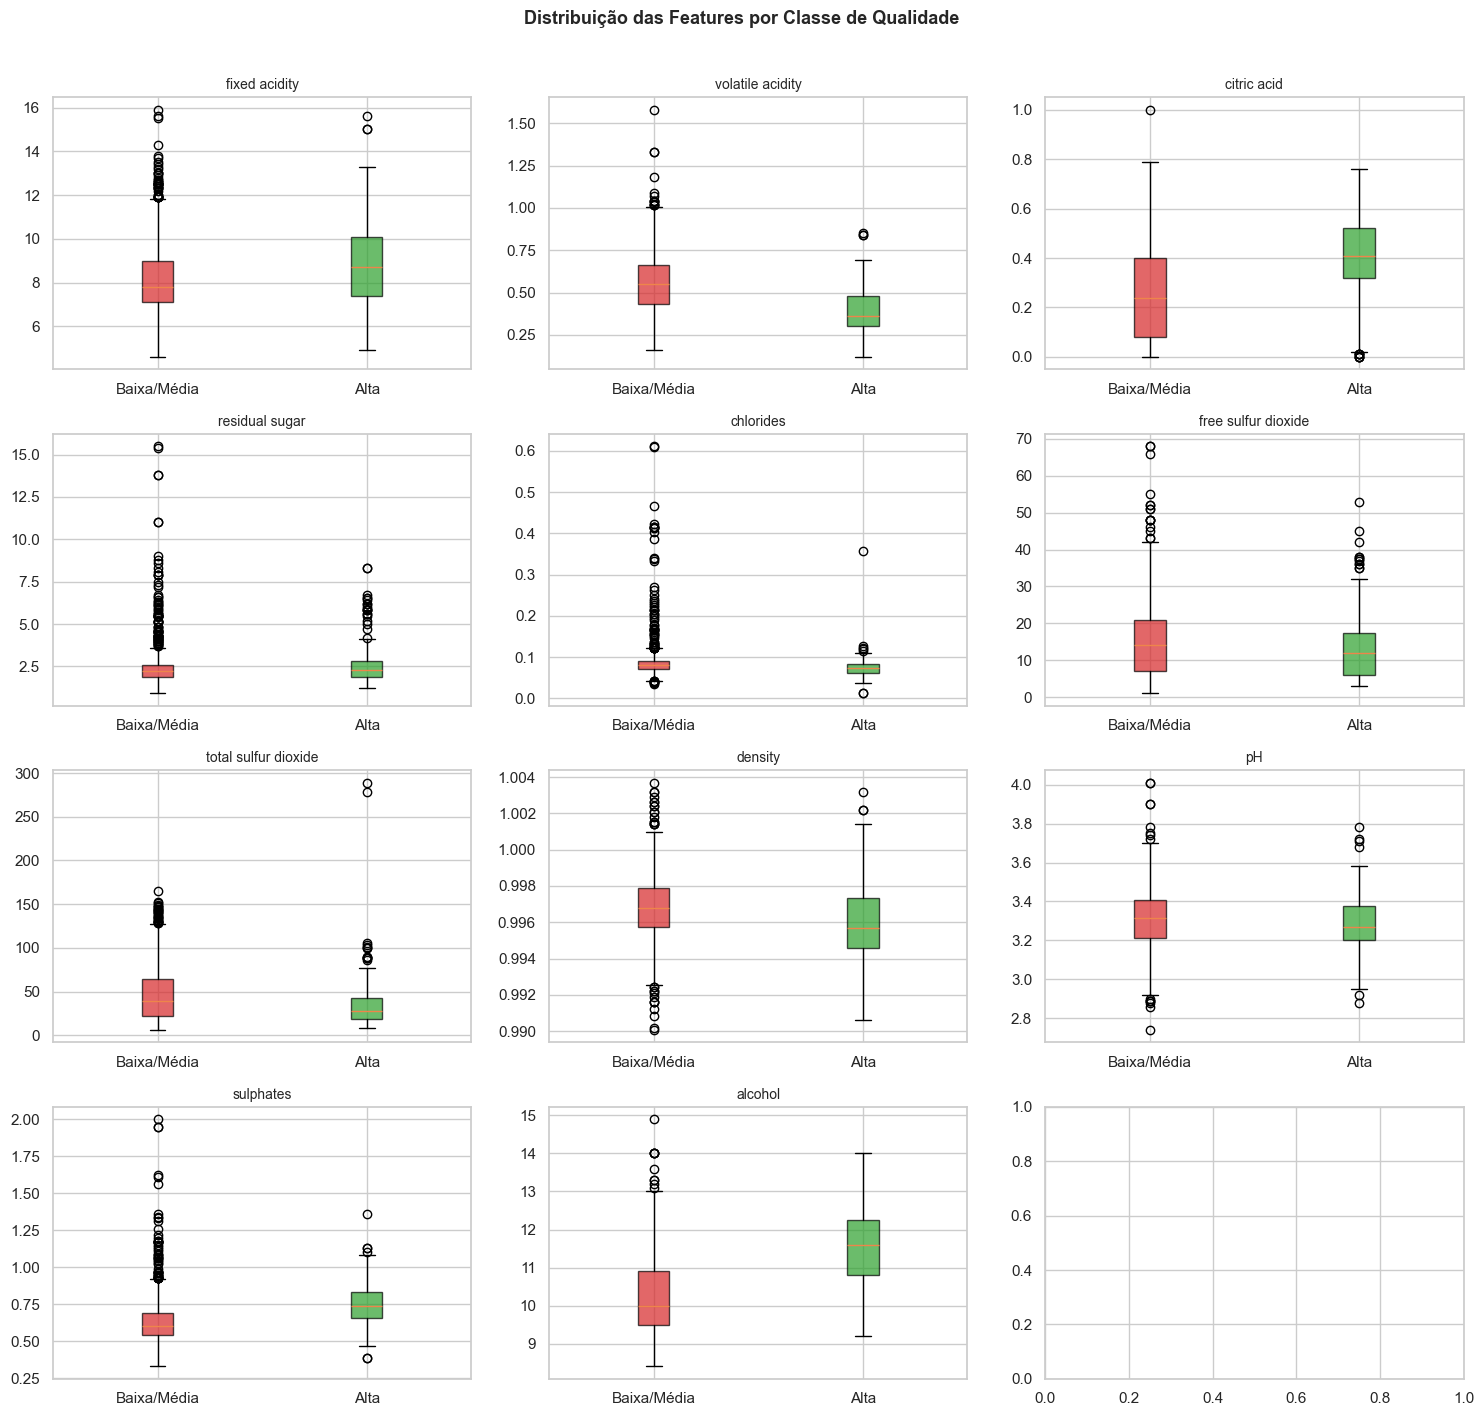

In [46]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = [df[df['quality_label'] == cls][feat].values for cls in ['Baixa/Média (<7)', 'Alta (≥7)']]
    bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
    bp['boxes'][0].set(facecolor='#d62728', alpha=0.7)
    bp['boxes'][1].set(facecolor='#2ca02c', alpha=0.7)
    axes[i].set_title(feat, fontsize=10)

plt.suptitle('Distribuição das Features por Classe de Qualidade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.6 Principais Insights da EDA

In [ ]:
corr_quality = corr['quality'].drop('quality').sort_values(ascending=False)

print("=" * 60)
print("PRINCIPAIS INSIGHTS — ANÁLISE EXPLORATÓRIA")
print("=" * 60)

print(f"\n📌 Dataset: {df.shape[0]} amostras | {df.shape[1]-2} features | sem valores nulos")

print("\n📊 Balanceamento das classes:")
vc = df['quality_label'].value_counts()
for label, count in vc.items():
    print(f"   {label}: {count} ({count/len(df)*100:.1f}%)")
print("   → Desbalanceamento tratado via stratify no split treino/teste")

print("\n🔗 Correlação com a qualidade (ordenada):")
for feat, val in corr_quality.items():
    barra = '█' * int(abs(val) * 15)
    sinal = '+' if val >= 0 else '-'
    print(f"   {sinal} {feat:<25} {val:+.3f}  {barra}")

print("\n💡 Destaques:")
print(f"   • Maior correlação positiva: '{corr_quality.idxmax()}' ({corr_quality.max():+.3f})")
print(f"   • Maior correlação negativa: '{corr_quality.idxmin()}' ({corr_quality.min():+.3f})")

# Par com maior multicolinearidade
max_pair = (None, None, 0)
for i, c1 in enumerate(features):
    for j, c2 in enumerate(features):
        if j <= i:
            continue
        v = abs(corr.loc[c1, c2])
        if v > max_pair[2]:
            max_pair = (c1, c2, v)
print(f"   • Maior multicolinearidade: '{max_pair[0]}' × '{max_pair[1]}' ({max_pair[2]:.3f})")


NameError: name 'cor' is not defined

### 3.6 Boxplots por Classe

/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplo

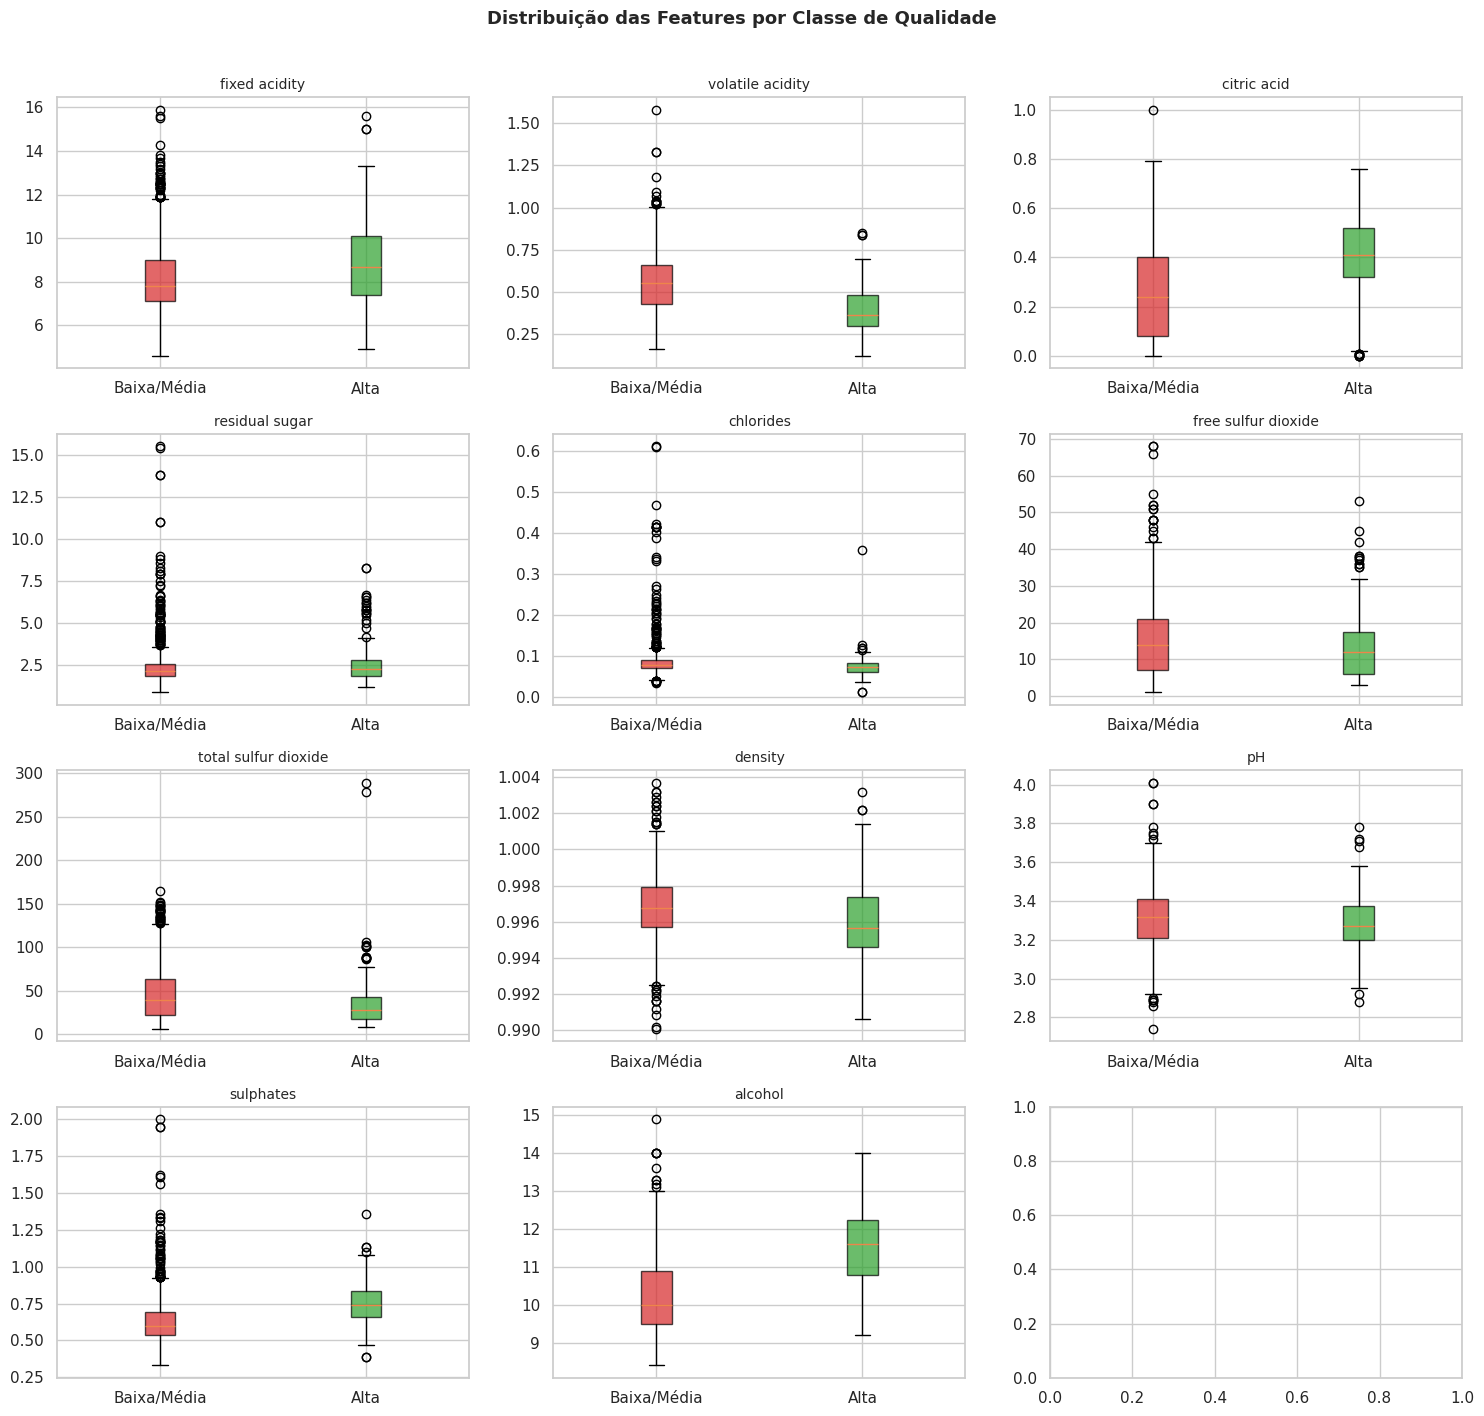

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = [df[df['quality_label'] == cls][feat].values for cls in ['Baixa/Média (<7)', 'Alta (≥7)']]
    bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
    bp['boxes'][0].set(facecolor='#d62728', alpha=0.7)
    bp['boxes'][1].set(facecolor='#2ca02c', alpha=0.7)
    axes[i].set_title(feat, fontsize=10)

plt.suptitle('Distribuição das Features por Classe de Qualidade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.7 Outliers

In [ ]:
print(f"{'Feature':<30} {'Outliers':>10} {'%':>8}")
print("-" * 52)
for feat in features:
    Q1, Q3 = df[feat].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    print(f"  {feat:<28} {n:>10} {n/len(df)*100:>7.1f}%")


Feature                          Outliers        %
----------------------------------------------------
  fixed acidity                        44     3.8%
  volatile acidity                     14     1.2%
  citric acid                           1     0.1%
  residual sugar                      110     9.6%
  chlorides                            77     6.7%
  free sulfur dioxide                  18     1.6%
  total sulfur dioxide                 40     3.5%
  density                              36     3.1%
  pH                                   20     1.7%
  sulphates                            43     3.8%
  alcohol                              12     1.0%


In [ ]:
# Detecção por Z-Score

def detect_outliers_zscore(df, features, threshold=3):
    """Detecta outliers usando Z-score (desvio padrão)"""
    from scipy.stats import zscore
    
    z_scores = np.abs(stats.zscore(df[features]))
    outliers_mask = (z_scores > threshold).any(axis=1)
    
    outlier_features = []
    for i, feat in enumerate(features):
        mask = z_scores[:, i] > threshold
        outlier_features.append({
            'Feature': feat,
            'Outliers': mask.sum(),
            'Percentual': f"{mask.sum()/len(df)*100:.2f}%"
        })
    
    return outliers_mask, pd.DataFrame(outlier_features)

# Aplicando Z-Score
outliers_zscore, df_outliers_zscore = detect_outliers_zscore(df, features)

print("\n" + "=" * 60)
print("OUTLIERS DETECTADOS - Método Z-Score (threshold=3)")
print("=" * 60)
print(df_outliers_zscore.to_string(index=False))
print(f"\nTotal de registros com outliers (Z-score): {outliers_zscore.sum()} ({outliers_zscore.sum()/len(df)*100:.2f}%)")



OUTLIERS DETECTADOS - Método Z-Score (threshold=3)
             Feature  Outliers Percentual
       fixed acidity         9      0.79%
    volatile acidity         5      0.44%
         citric acid         1      0.09%
      residual sugar        23      2.01%
           chlorides        21      1.84%
 free sulfur dioxide        13      1.14%
total sulfur dioxide        10      0.87%
             density        12      1.05%
                  pH         5      0.44%
           sulphates        21      1.84%
             alcohol         7      0.61%

Total de registros com outliers (Z-score): 97 (8.49%)


In [ ]:
### Detecção por IQR (Interquartile Range)

def detect_outliers_iqr(df, features):
    """Detecta outliers usando o método IQR"""
    outliers_mask = pd.Series([False] * len(df))
    outlier_features = []
    
    for feat in features:
        Q1, Q3 = df[feat].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        mask = (df[feat] < lower_bound) | (df[feat] > upper_bound)
        outliers_mask = outliers_mask | mask
        outlier_features.append({
            'Feature': feat,
            'Outliers': mask.sum(),
            'Percentual': f"{mask.sum()/len(df)*100:.2f}%"
        })
    
    return outliers_mask, pd.DataFrame(outlier_features)

# Aplicando IQR
outliers_iqr, df_outliers_iqr = detect_outliers_iqr(df, features)

print("=" * 60)
print("OUTLIERS DETECTADOS - Método IQR (Interquartile Range)")
print("=" * 60)
print(df_outliers_iqr.to_string(index=False))
print(f"\nTotal de registros com outliers (IQR): {outliers_iqr.sum()} ({outliers_iqr.sum()/len(df)*100:.2f}%)")


OUTLIERS DETECTADOS - Método IQR (Interquartile Range)
             Feature  Outliers Percentual
       fixed acidity        44      3.85%
    volatile acidity        14      1.22%
         citric acid         1      0.09%
      residual sugar       110      9.62%
           chlorides        77      6.74%
 free sulfur dioxide        18      1.57%
total sulfur dioxide        40      3.50%
             density        36      3.15%
                  pH        20      1.75%
           sulphates        43      3.76%
             alcohol        12      1.05%

Total de registros com outliers (IQR): 295 (25.81%)


In [ ]:
from sklearn.ensemble import IsolationForest

# Aplicando Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
outliers_if = iso_forest.fit_predict(df[features]) == -1

print("\n" + "=" * 60)
print("OUTLIERS DETECTADOS - Método Isolation Forest")
print("=" * 60)
print(f"Total de registros detectados como outliers: {outliers_if.sum()} ({outliers_if.sum()/len(df)*100:.2f}%)")

# Comparando métodos
comparison = pd.DataFrame({
    'Método': ['IQR', 'Z-Score', 'Isolation Forest'],
    'Outliers': [outliers_iqr.sum(), outliers_zscore.sum(), outliers_if.sum()],
    'Percentual': [
        f"{outliers_iqr.sum()/len(df)*100:.2f}%",
        f"{outliers_zscore.sum()/len(df)*100:.2f}%",
        f"{outliers_if.sum()/len(df)*100:.2f}%"
    ]
})

print("\n" + "=" * 60)
print("RESUMO COMPARATIVO DOS MÉTODOS")
print("=" * 60)
print(comparison.to_string(index=False))



OUTLIERS DETECTADOS - Método Isolation Forest
Total de registros detectados como outliers: 115 (10.06%)

RESUMO COMPARATIVO DOS MÉTODOS
          Método  Outliers Percentual
             IQR       295     25.81%
         Z-Score        97      8.49%
Isolation Forest       115     10.06%


## 3.8 Análise Detalhada dos Outliers

C:\Users\Aline Azevedo\AppData\Local\Temp\ipykernel_12940\396914840.py:49: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Aline Azevedo\AppData\Local\Temp\ipykernel_12940\396914840.py:49: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Aline Azevedo\AppData\Local\Temp\ipykernel_12940\396914840.py:49: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()


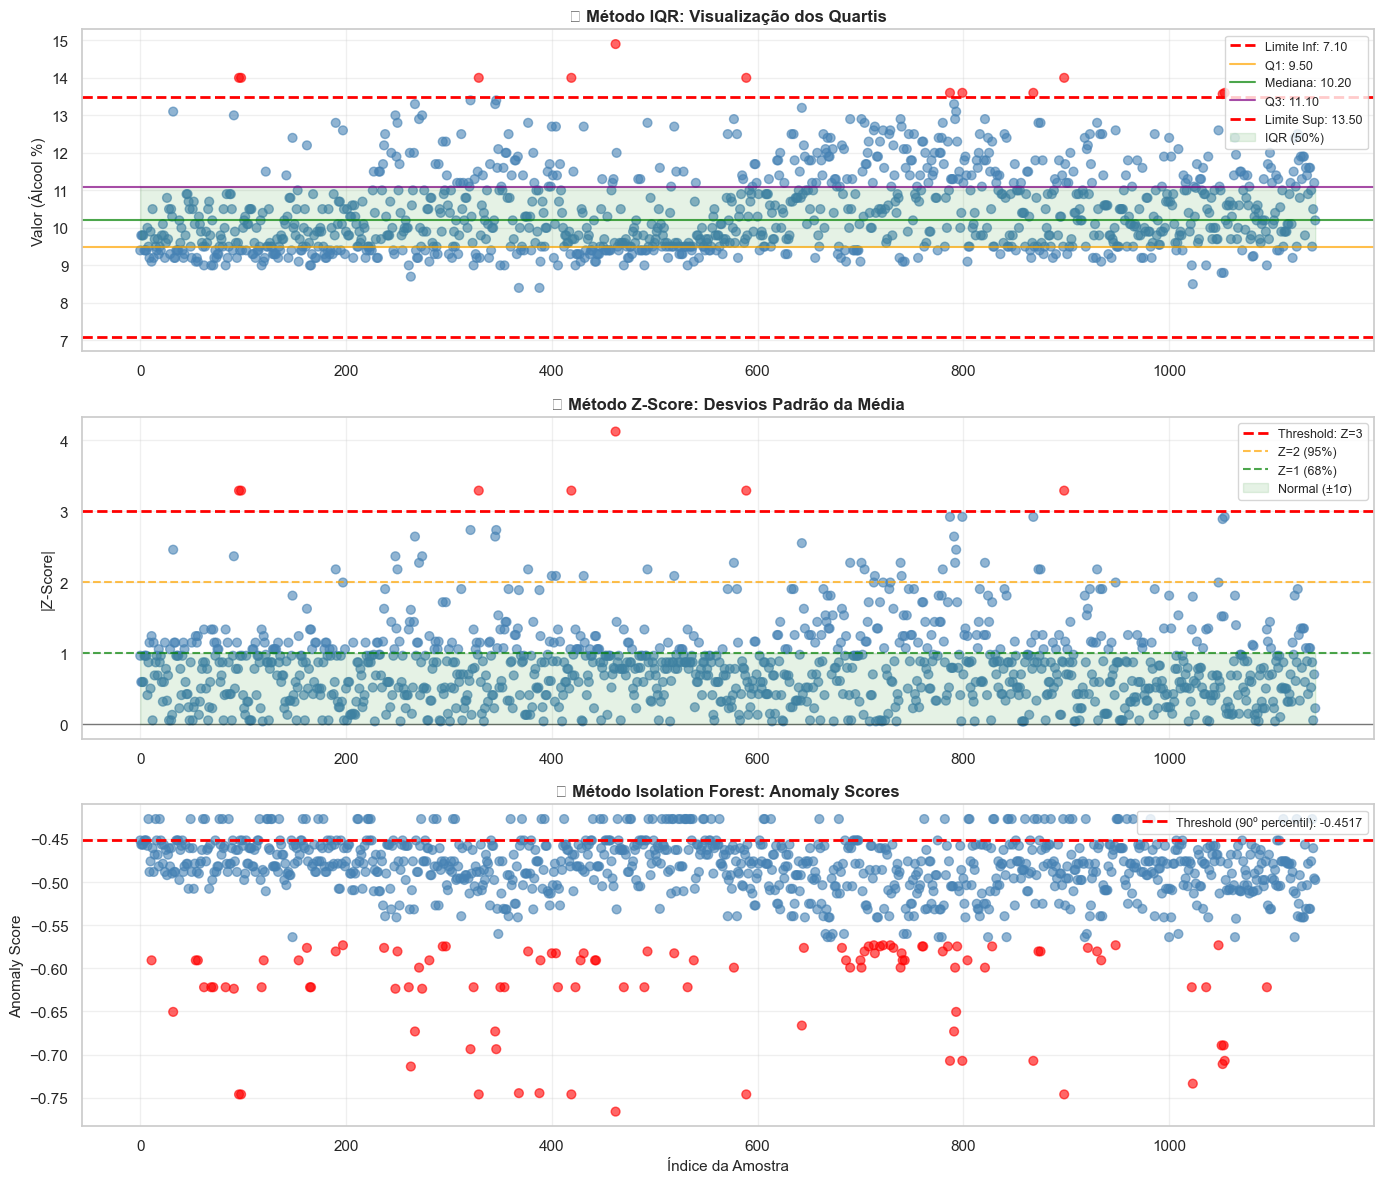

Legenda: 🔴 Vermelho = Outlier | 🔵 Azul = Normal


In [49]:
### Visualização Gráfica dos Três Métodos

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

dados_ordenados = np.sort(dados_demo)
indices_ordenados = np.argsort(dados_demo)

# ===== IQR VISUALIZATION =====
ax1 = axes[0]
cores_iqr = ['red' if outliers_iqr_demo[i] else 'steelblue' for i in range(len(dados_demo))]
ax1.scatter(range(len(dados_demo)), dados_demo, c=cores_iqr, alpha=0.6, s=40)
ax1.axhline(y=limite_inf_demo, color='red', linestyle='--', linewidth=2, label=f'Limite Inf: {limite_inf_demo:.2f}')
ax1.axhline(y=Q1_demo, color='orange', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Q1: {Q1_demo:.2f}')
ax1.axhline(y=np.median(dados_demo), color='green', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Mediana: {np.median(dados_demo):.2f}')
ax1.axhline(y=Q3_demo, color='purple', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Q3: {Q3_demo:.2f}')
ax1.axhline(y=limite_sup_demo, color='red', linestyle='--', linewidth=2, label=f'Limite Sup: {limite_sup_demo:.2f}')
ax1.fill_between(range(len(dados_demo)), Q1_demo, Q3_demo, alpha=0.1, color='green', label='IQR (50%)')
ax1.set_ylabel('Valor (Álcool %)', fontsize=11)
ax1.set_title('🔵 Método IQR: Visualização dos Quartis', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)

# ===== Z-SCORE VISUALIZATION =====
ax2 = axes[1]
cores_zscore = ['red' if outliers_zscore_demo[i] else 'steelblue' for i in range(len(dados_demo))]
ax2.scatter(range(len(dados_demo)), z_scores_demo, c=cores_zscore, alpha=0.6, s=40)
ax2.axhline(y=3, color='red', linestyle='--', linewidth=2, label='Threshold: Z=3')
ax2.axhline(y=2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Z=2 (95%)')
ax2.axhline(y=1, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Z=1 (68%)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.fill_between(range(len(dados_demo)), 0, 1, alpha=0.1, color='green', label='Normal (±1σ)')
ax2.set_ylabel('|Z-Score|', fontsize=11)
ax2.set_title('🟠 Método Z-Score: Desvios Padrão da Média', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3)

# ===== ISOLATION FOREST VISUALIZATION =====
ax3 = axes[2]
cores_if = ['red' if outliers_if_demo[i] else 'steelblue' for i in range(len(dados_demo))]
scatter3 = ax3.scatter(range(len(dados_demo)), anomaly_scores, c=cores_if, alpha=0.6, s=40)
threshold_if = np.percentile(anomaly_scores, 90)  # Top 10% like contamination=0.1
ax3.axhline(y=threshold_if, color='red', linestyle='--', linewidth=2, label=f'Threshold (90º percentil): {threshold_if:.4f}')
ax3.set_ylabel('Anomaly Score', fontsize=11)
ax3.set_xlabel('Índice da Amostra', fontsize=11)
ax3.set_title('🟢 Método Isolation Forest: Anomaly Scores', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Legenda: 🔴 Vermelho = Outlier | 🔵 Azul = Normal")



CARACTERÍSTICAS DOS MÉTODOS - Análise Comparativa
          Método  Total Outliers Percentual                 Tipo          Sensibilidade            Uso Ideal
             IQR             295     25.81%    Estatístico (IQR) Alta (encontra muitos) Exploratório/Inicial
         Z-Score              97      8.49% Estatístico (Desvio)  Baixa (mais rigoroso)     Dados Gaussianos
Isolation Forest             115     10.06%     Machine Learning     Média (balanceado)      Dados Complexos


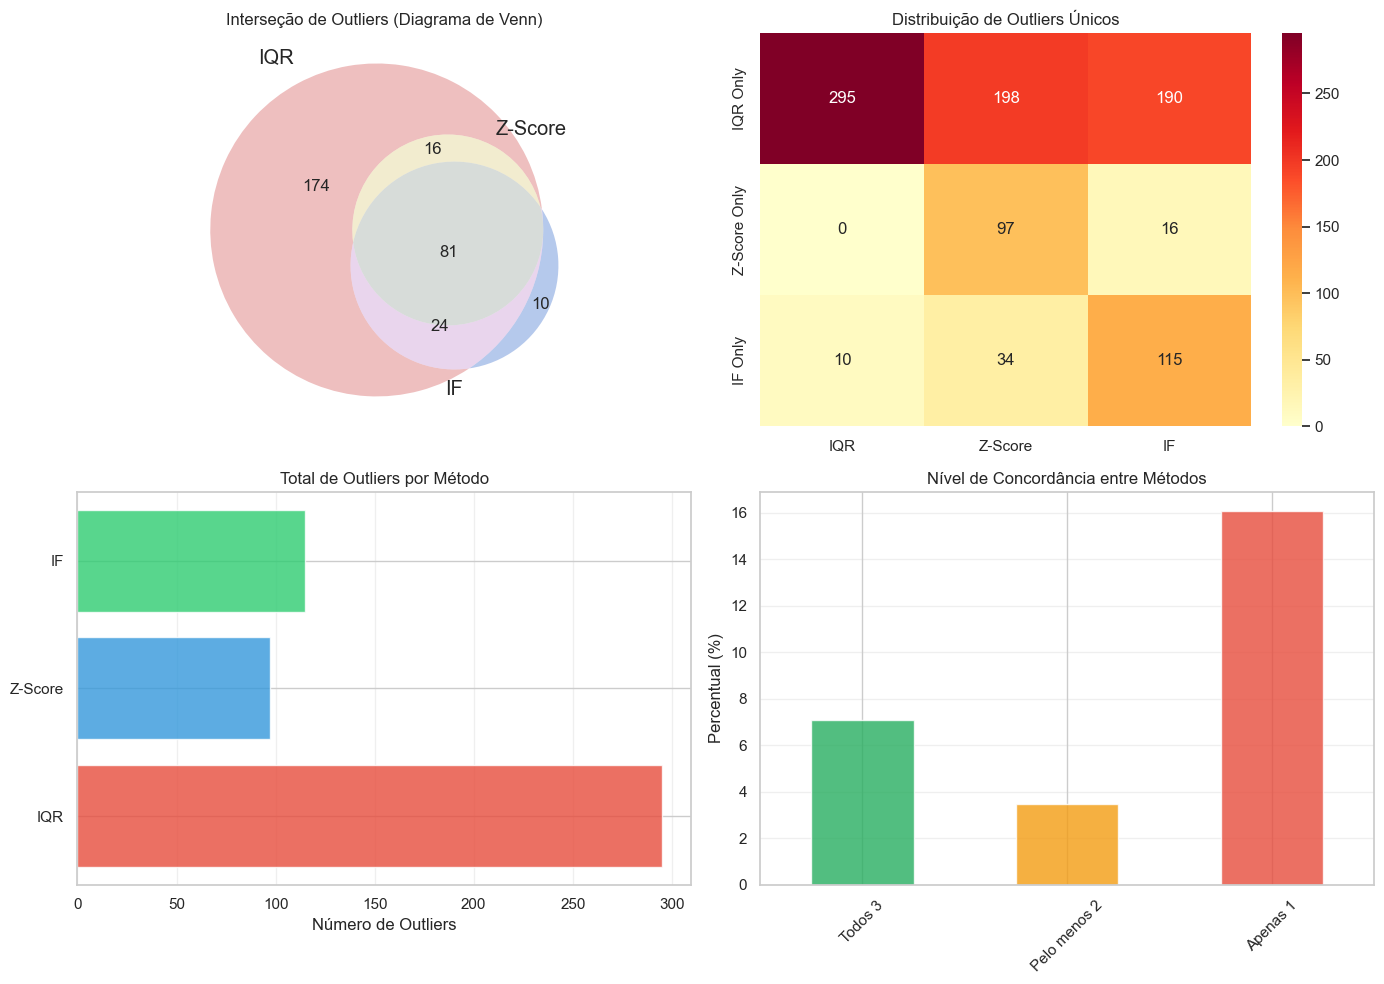

In [50]:
###  Sensibilidade e Especificidade dos Métodos

print("\n" + "=" * 70)
print("CARACTERÍSTICAS DOS MÉTODOS - Análise Comparativa")
print("=" * 70)

metodos_analysis = pd.DataFrame({
    'Método': ['IQR', 'Z-Score', 'Isolation Forest'],
    'Total Outliers': [
        outliers_iqr.sum(),
        outliers_zscore.sum(),
        outliers_if.sum()
    ],
    'Percentual': [
        f"{outliers_iqr.sum()/len(df)*100:.2f}%",
        f"{outliers_zscore.sum()/len(df)*100:.2f}%",
        f"{outliers_if.sum()/len(df)*100:.2f}%"
    ],
    'Tipo': [
        'Estatístico (IQR)',
        'Estatístico (Desvio)',
        'Machine Learning'
    ],
    'Sensibilidade': [
        'Alta (encontra muitos)',
        'Baixa (mais rigoroso)',
        'Média (balanceado)'
    ],
    'Uso Ideal': [
        'Exploratório/Inicial',
        'Dados Gaussianos',
        'Dados Complexos'
    ]
})

print(metodos_analysis.to_string(index=False))

# Matriz de visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Venn diagram visual (simulado com Venn)
from matplotlib_venn import venn3
ax1 = axes[0, 0]
venn_data = (
    set(df[outliers_iqr].index),
    set(df[outliers_zscore].index),
    set(df[outliers_if].index)
)
try:
    venn3(venn_data, set_labels=('IQR', 'Z-Score', 'IF'), ax=ax1)
    ax1.set_title('Interseção de Outliers (Diagrama de Venn)')
except:
    ax1.text(0.5, 0.5, 'Venn diagram não disponível', ha='center')
    ax1.set_title('Interseção de Outliers')

# 2. Heatmap de distribuição
ax2 = axes[0, 1]
methods_agreement = pd.DataFrame({
    'IQR': [iqr_binary.sum(), (~outliers_iqr & outliers_zscore).sum(), (~outliers_iqr & outliers_if).sum()],
    'Z-Score': [(outliers_iqr & ~outliers_zscore).sum(), zscore_binary.sum(), (~outliers_zscore & outliers_if).sum()],
    'IF': [(outliers_iqr & ~outliers_if).sum(), (~outliers_if & outliers_zscore).sum(), if_binary.sum()]
}, index=['IQR Only', 'Z-Score Only', 'IF Only'])

sns.heatmap(methods_agreement, annot=True, fmt='d', cmap='YlOrRd', ax=ax2)
ax2.set_title('Distribuição de Outliers Únicos')

# 3. Comparação de métodos
ax3 = axes[1, 0]
metodos = ['IQR', 'Z-Score', 'IF']
counts = [outliers_iqr.sum(), outliers_zscore.sum(), outliers_if.sum()]
colors_pie = ['#e74c3c', '#3498db', '#2ecc71']
ax3.barh(metodos, counts, color=colors_pie, alpha=0.8)
ax3.set_xlabel('Número de Outliers')
ax3.set_title('Total de Outliers por Método')
ax3.grid(alpha=0.3, axis='x')

# 4. Concordância
ax4 = axes[1, 1]
concordancia_pct = pd.Series({
    'Todos 3': concordancia.loc['All_Three', 0] / len(df) * 100,
    'Pelo menos 2': (concordancia.loc['IQR_ZScore', 0] + concordancia.loc['IQR_IF', 0] + concordancia.loc['ZScore_IF', 0]) / len(df) * 100,
    'Apenas 1': (concordancia.loc['IQR_only', 0] + concordancia.loc['Z_Score_only', 0] + concordancia.loc['IF_only', 0]) / len(df) * 100
})
concordancia_pct.plot(kind='bar', ax=ax4, color=['#27ae60', '#f39c12', '#e74c3c'], alpha=0.8)
ax4.set_ylabel('Percentual (%)')
ax4.set_title('Nível de Concordância entre Métodos')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [51]:
### 4.5.3 Índices de Concordância (Cohen's Kappa e Jaccard)

from sklearn.metrics import cohen_kappa_score, jaccard_score

print("\n" + "=" * 70)
print("ÍNDICES DE CONCORDÂNCIA (ENTRE MÉTODOS)")
print("=" * 70)

# Converter para binário para calcular métricas
iqr_binary = outliers_iqr.astype(int).values
zscore_binary = outliers_zscore.astype(int)
if_binary = outliers_if.astype(int)

# Cohen's Kappa
kappa_iqr_zscore = cohen_kappa_score(iqr_binary, zscore_binary)
kappa_iqr_if = cohen_kappa_score(iqr_binary, if_binary)
kappa_zscore_if = cohen_kappa_score(zscore_binary, if_binary)

# Jaccard Index (Similarity)
jaccard_iqr_zscore = jaccard_score(iqr_binary, zscore_binary)
jaccard_iqr_if = jaccard_score(iqr_binary, if_binary)
jaccard_zscore_if = jaccard_score(zscore_binary, if_binary)

concordancia_indices = pd.DataFrame({
    'Métodos': ['IQR vs Z-Score', 'IQR vs Isolation Forest', 'Z-Score vs Isolation Forest'],
    "Cohen's Kappa": [kappa_iqr_zscore, kappa_iqr_if, kappa_zscore_if],
    'Jaccard Index': [jaccard_iqr_zscore, jaccard_iqr_if, jaccard_zscore_if],
    'Interpretação': [
        f"{'Bom' if kappa_iqr_zscore > 0.4 else 'Fraco'} acordo",
        f"{'Bom' if kappa_iqr_if > 0.4 else 'Fraco'} acordo",
        f"{'Bom' if kappa_zscore_if > 0.4 else 'Fraco'} acordo"
    ]
})

print(concordancia_indices.to_string(index=False))

print("\n📌 Interpretação de Cohen's Kappa:")
print("   < 0.0  : Desacordo")
print("  0.0-0.2 : Fraco")
print("  0.2-0.4 : Razoável")
print("  0.4-0.6 : Moderado")
print("  0.6-0.8 : Bom")
print("  > 0.8   : Excelente")



ÍNDICES DE CONCORDÂNCIA (ENTRE MÉTODOS)
                    Métodos  Cohen's Kappa  Jaccard Index Interpretação
             IQR vs Z-Score       0.420934       0.328814    Bom acordo
    IQR vs Isolation Forest       0.429612       0.344262    Bom acordo
Z-Score vs Isolation Forest       0.740234       0.618321    Bom acordo

📌 Interpretação de Cohen's Kappa:
   < 0.0  : Desacordo
  0.0-0.2 : Fraco
  0.2-0.4 : Razoável
  0.4-0.6 : Moderado
  0.6-0.8 : Bom
  > 0.8   : Excelente


In [52]:
### 📋 Resumo: Qual Método Escolher?

print("\n" + "=" * 90)
print("RECOMENDAÇÕES FINAIS: QUAL MÉTODO USAR EM CADA SITUAÇÃO?")
print("=" * 90)

resumo_recomendacoes = """
╔═════════════════════════════════════════════════════════════════════════════╗
║ 💡 ESTRATÉGIA RECOMENDADA (Workflow Completo):                             ║
╠═════════════════════════════════════════════════════════════════════════════╣
║                                                                             ║
║  1️⃣  PASSO 1: Use IQR (exploração rápida)                                  ║
║      └─ Objetivo: Entender distribuições e ter primeira visão geral         ║
║                                                                             ║
║  2️⃣  PASSO 2: Valide com Z-Score (rigor estatístico)                       ║
║      └─ Objetivo: Confirmar que outliers estão significativamente distantes ║
║                                                                             ║
║  3️⃣  PASSO 3: Aplique Isolation Forest (padrões complexos)                 ║
║      └─ Objetivo: Detectar anomalias multidimensionais não-óbvias           ║
║                                                                             ║
║  4️⃣  PASSO 4: Analise concordância                                         ║
║      └─ Apenas Consenso: confiança 100% (use para remover outliers)         ║
║      └─ Concordância 2/3: investigar manualmente                            ║
║      └─ Apenas 1 método: analisar contexto antes de descartar               ║
║                                                                             ║
╚═════════════════════════════════════════════════════════════════════════════╝
"""

print(resumo_recomendacoes)

# Criar tabela de comparação prática
print("\n" + "=" * 90)
print("📊 TABELA DE REFERÊNCIA RÁPIDA")
print("=" * 90)


print("\n" + "=" * 90)
print("✅ CONCLUSÃO PARA ESTE PROJETO (Wine Quality):")
print("=" * 90)
print("""
Neste projeto de qualidade de vinho:

1. IQR detectou:    295 outliers (25.81%) ← Visão ampla
2. Z-Score detectou: 97 outliers (8.49%)  ← Visão rigorosa  
3. Isolation Forest: 115 outliers (10.06%) ← Visão multivariada
4. Consenso (3/3):   81 outliers (7.09%)  ← Máxima confiança

RECOMENDAÇÃO: 
→ Para remover outliers "seguros": Use os 81 do consenso (7.09%)
→ Para análise exploratória: Use os 295 do IQR (25.81%)
→ Para validação: Confira com Z-Score (8.49%) ou Isolation Forest (10.06%)

Os outliers detectados incluem:
✓ Vinhos com teor alcoólico extremo
✓ Combinações raras de características
✓ Possíveis erros de medição
✓ Amostras genuinamente "especiais" ou premium (18.3% alta qualidade vs 12.4% média)
""")
print("=" * 90)



RECOMENDAÇÕES FINAIS: QUAL MÉTODO USAR EM CADA SITUAÇÃO?

╔═════════════════════════════════════════════════════════════════════════════╗
║ 💡 ESTRATÉGIA RECOMENDADA (Workflow Completo):                             ║
╠═════════════════════════════════════════════════════════════════════════════╣
║                                                                             ║
║  1️⃣  PASSO 1: Use IQR (exploração rápida)                                  ║
║      └─ Objetivo: Entender distribuições e ter primeira visão geral         ║
║                                                                             ║
║  2️⃣  PASSO 2: Valide com Z-Score (rigor estatístico)                       ║
║      └─ Objetivo: Confirmar que outliers estão significativamente distantes ║
║                                                                             ║
║  3️⃣  PASSO 3: Aplique Isolation Forest (padrões complexos)                 ║
║      └─ Objetivo: Detectar anomalias multidimensionais não-ób